In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
import keras
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
data_dir

'./datasets/flower_photos'

In [ ]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [ ]:
import os
print(os.listdir(data_dir))

['flower_photos']


In [ ]:
data_dir = data_dir / 'flower_photos'
print(data_dir)

datasets/flower_photos/flower_photos


In [ ]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/14687731322_5613f76353.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15697872479_ed48e9dd73_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/13264214185_d6aa79b3bd.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9338237628_4d2547608c.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5360769702_ec28c53b9e_n.jpg')]

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [ ]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/14687731322_5613f76353.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15697872479_ed48e9dd73_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/13264214185_d6aa79b3bd.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9338237628_4d2547608c.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5360769702_ec28c53b9e_n.jpg')]

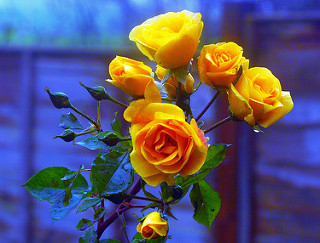

In [ ]:
PIL.Image.open(str(roses[1]))

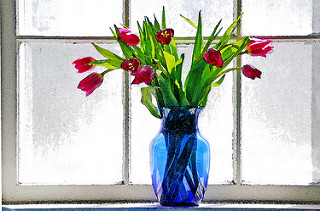

In [ ]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [ ]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/14687731322_5613f76353.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15697872479_ed48e9dd73_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/13264214185_d6aa79b3bd.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9338237628_4d2547608c.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5360769702_ec28c53b9e_n.jpg')]

In [ ]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape
cv2.resize(img,(180,180)).shape
X, y = [], []
for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

***data augmentation***

In [ ]:
img_height = 180
img_width = 180

data_augmentation = keras.Sequential(
  [
    keras.Input(shape=(img_height, img_width, 3)), # Explicitly define the input shape here
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

In [ ]:
plt.axis('off')
plt.imshow(X[1])

NameError: name 'plt' is not defined

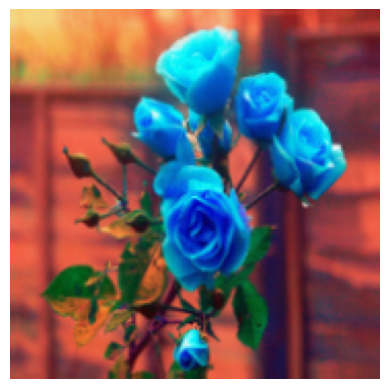

In [ ]:
plt.axis('off')
plt.imshow(data_augmentation(X)[1].numpy().astype("uint8"))

In [ ]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 874ms/step - accuracy: 0.3808 - loss: 1.4905
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 74s 789ms/step - accuracy: 0.5727 - loss: 1.0640
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 804ms/step - accuracy: 0.6337 - loss: 0.9618
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 753ms/step - accuracy: 0.6541 - loss: 0.8922
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 755ms/step - accuracy: 0.6726 - loss: 0.8473


In [ ]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.6111 - loss: 1.0178


[1.0178163051605225, 0.6111111044883728]

In [ ]:
model.predict(np.expand_dims(X_test_scaled[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[ 1.6213685 ,  4.9121733 , -0.60995173, -1.0045629 ,  0.6478262 ]],
      dtype=float32)